# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import sys
import shap
from itertools import product as iproduct

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV, mutual_info_classif
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                             average_precision_score, precision_recall_curve, make_scorer)
from sklearn.model_selection import (train_test_split, PredefinedSplit, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, loguniform
from scipy.ndimage import uniform_filter1d

from lifelines import CoxPHFitter, KaplanMeierFitter
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

#!{sys.executable} -m pip install scikit-survival
#!conda install -c conda-forge scikit-survival -y
#pip install scikit-survival

In [2]:
#!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
#!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/msys2

In [3]:
# Style settings for presentation charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

<a class="anchor" id="1.1 Import Libraries">

## 1.2 Data Loading
    
</a>

In [4]:
#catarina
#file_path_BNP = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_BNP_teste = r"C:\Users\Catarina\Documents\GitHub\BNP-Paribas\Preprocessed_dataset_BNP2_teste.csv"

# Read the parquet file
#BNP = pd.read_csv(file_path_BNP)
BNP_teste = pd.read_csv(file_path_BNP_teste)

# Load the preprocessed dataset
df = pd.read_csv(file_path_BNP_teste)

In [5]:
#Alano
file_path_BNP_teste = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\Preprocessed_dataset_BNP2_teste.csv"
BNP_teste = pd.read_csv(file_path_BNP_teste)
df = pd.read_csv(file_path_BNP_teste)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\alano\\Desktop\\Mestrado\\2- Semestre\\Busines case\\BNP\\Projeto GIt\\BNP-Paribas\\Preprocessed_dataset_BNP2_teste.csv'

In [92]:
BNP_teste[BNP_teste['CHURN'] == True]

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,...,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,...,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,...,Unknown,1,1.0,60.0,0.178571,8,C,A,44,0.166667
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,...,Unknown,1,1.0,60.0,0.178571,8,C,A,44,0.166667
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,1,0,2019-01-28,2024-01-31,2024-01-31,72,34,34,...,Unknown,1,1.0,0.0,0.000000,3,S,A,69,0.000000
8,000406feeb8088e3b05f47bc89160d25ca14f11c31f91b...,a87dd90b5a28bd8cbeb9b20e4dd8a169da6cbf7df649cd...,0,1,2007-06-29,2024-03-31,2024-03-31,84,24,24,...,Unknown,1,1.0,0.0,0.000000,7,V,P,74,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185593,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,78350b49408237d9be0249768a20c97f5b40f8260b0a46...,1,0,2021-10-26,2024-10-31,2024-10-31,84,36,61,...,Unknown,1,1.0,0.0,0.000000,23,C,P,61,0.083333
185594,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,44646b249bca38e9954ca24c81aa0dd55c1f286a257394...,0,1,2022-09-27,2024-09-30,2024-09-30,24,24,61,...,Unknown,1,1.0,0.0,0.000000,23,C,P,61,0.083333
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,0,1,2021-02-12,2024-01-31,2024-01-31,34,34,34,...,Unknown,1,1.0,0.0,0.000000,4,S,P,33,0.200000
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,1,0,2022-03-24,2024-03-31,2024-03-31,84,23,34,...,Unknown,1,1.0,156.0,0.064103,17,X,F,33,0.055556


<a class="anchor" id="1.1 Import Libraries">

## 2. Target Engineering
    
</a>

In [5]:
# 1. Classification Target (Binary)
df['TARGET'] = df['CHURN'].fillna(0).astype(int)

# 2. Survival Targets (Event and Duration)
df['event'] = df['TARGET']
# Ensure duration is at least 1 day so Cox doesn't crash
df['duration'] = df['DOSSIER_DURATION_DAYS'].clip(lower=1).fillna(1)
df['CLOSE_DATE'] = pd.to_datetime(df['CLOSE_DATE'])

In [6]:
features_for_survival = [
    'DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC',
    'RESSO_mean', 'NBENF_mean',
    'N_PREVIOUS_DOSSIERS', 'previous_churn_rate',
    'count_cl_mean', 'subcount_total_mean', 'montvenc_cl_mean', 'montenc_total_mean',
    'montabatv_cl_mean', 'montabatv_total_mean', 'dividas_cl_mean', 
    'dividas_total_mean', 'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky',
    'sdem_age', 'active_credit_ratio', 'POLE', 'PRODALP', 'PAGAMENTO', 
    'MODCONTACTO', 'sdem_SITFAM', 'sdem_HABITAT', 'kp_sqe', 'NATIO',
    'AGFIN', 'PTT'
]

<a class="anchor" id="1.1 Import Libraries">

## 3. Split
    
</a>

In [7]:
train_df = df[df['CLOSE_DATE'].notna()].copy()
test_df = df[df['CLOSE_DATE'].isna()].copy()

In [8]:
# Temporal split: train on oldest contracts, validate on most recent
train_df_sorted = train_df.sort_values('CLOSE_DATE')

# 80% oldest -> train | 20% most recent -> validation
cutoff = train_df_sorted['CLOSE_DATE'].quantile(0.8)
train_data = train_df_sorted[train_df_sorted['CLOSE_DATE'] <= cutoff].copy()
val_data   = train_df_sorted[train_df_sorted['CLOSE_DATE'] >  cutoff].copy()

print(f"Cutoff date: {cutoff.date()}")
print(f"Train size: {len(train_data):,} ({len(train_data)/len(train_df):.1%})")
print(f"Val size:   {len(val_data):,} ({len(val_data)/len(train_df):.1%})")
print(f"\nChurn rate train: {train_data['TARGET'].mean():.3f}")
print(f"Churn rate val:   {val_data['TARGET'].mean():.3f}")

Cutoff date: 2025-06-30
Train size: 63,118 (82.4%)
Val size:   13,528 (17.6%)

Churn rate train: 0.860
Churn rate val:   0.774


In [9]:
# Create X by selecting columns from our feature list
X_train = train_data[features_for_survival].copy()
X_val = val_data[features_for_survival].copy()
X_test = test_df[features_for_survival].copy()

# Create y targets
y_train = train_data['TARGET']
y_val = val_data['TARGET']

print("Shape X_train:", X_train.shape)
print("Shape X_val:", X_val.shape)

Shape X_train: (63118, 32)
Shape X_val: (13528, 32)


## SCALING

In [10]:
X_train

,DURDEG,MENSALIDADE,CRD_min,MTFINO,SREC,RESSO_mean,NBENF_mean,N_PREVIOUS_DOSSIERS,previous_churn_rate,count_cl_mean,...,POLE,PRODALP,PAGAMENTO,MODCONTACTO,sdem_SITFAM,sdem_HABITAT,kp_sqe,NATIO,AGFIN,PTT
92794,60,93.730818,0.0,5000.0,0.000000,993.649000,0.0,0,-1.0,1.720000,...,P,EP,P,T,S,A,Unknown,P,117.0,2305
84813,76,161.798899,0.0,8000.0,0.000000,1867.787000,0.0,0,-1.0,2.840000,...,P,EP,P,W,X,A,Unknown,P,118.0,4715
84810,24,272.163616,0.0,5000.0,0.000000,1079.225000,1.0,0,-1.0,1.320000,...,P,EP,P,A,S,P,G,P,117.0,3515
84806,84,109.792569,0.0,5000.0,0.000000,1170.522000,2.0,0,-1.0,1.000000,...,P,EP,P,W,C,A,Unknown,P,117.0,7960
84804,84,996.257424,0.0,45000.0,0.000000,3061.034000,0.0,0,-1.0,3.428571,...,P,EXT,P,A,C,P,Unknown,P,117.0,4820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130031,84,157.476604,0.0,8000.0,26.613778,1418.482000,1.0,1,1.0,0.000000,...,P,EP,P,W,C,P,A,P,118.0,2900
28881,72,103.738695,0.0,5000.0,0.000000,1113.258000,0.0,0,-1.0,0.473684,...,P,EP,P,A,S,A,A,P,118.0,8400
63678,42,98.613323,0.0,3000.0,0.000000,1147.330000,0.0,0,-1.0,3.200000,...,P,EP,P,W,U,P,Unknown,P,118.0,2910
132089,80,234.950822,0.0,11500.0,0.000000,1381.379000,0.0,0,-1.0,1.000000,...,P,EP,P,W,X,F,Unknown,P,118.0,6060


In [11]:
'''# select numerical columns
num_cols = X_train.select_dtypes(include=np.number).columns

# create scaler
scaler = RobustScaler()

# scale only numerical columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])'''

'# select numerical columns\nnum_cols = X_train.select_dtypes(include=np.number).columns\n\n# create scaler\nscaler = RobustScaler()\n\n# scale only numerical columns\nX_train[num_cols] = scaler.fit_transform(X_train[num_cols])'

## Encoding

In [12]:
# Convert AGFIN and PTT to string (categorical but stored as numbers)
for col in ['AGFIN', 'PTT']:
    X_train[col] = X_train[col].astype(str)
    X_val[col]   = X_val[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

# Identify text columns within our filtered X_train
cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    # 2. Calculate frequency in Train
    freq_map = X_train[col].value_counts(normalize=True)

    # 3. Create the new variable with _encoded suffix
    X_train[f"{col}_encoded"] = X_train[col].map(freq_map)
    X_val[f"{col}_encoded"]   = X_val[col].map(freq_map).fillna(0)
    X_test[f"{col}_encoded"]  = X_test[col].map(freq_map).fillna(0)

    # 4. Drop original column to avoid confusing the model
    X_train = X_train.drop(columns=[col])
    X_val   = X_val.drop(columns=[col])
    X_test  = X_test.drop(columns=[col])

print(f"Encoding complete. Created '_encoded' versions for: {list(cat_cols)}")
print(f"Columns in X_train: {X_train.columns.tolist()}")

Encoding complete. Created '_encoded' versions for: ['POLE', 'PRODALP', 'PAGAMENTO', 'MODCONTACTO', 'sdem_SITFAM', 'sdem_HABITAT', 'kp_sqe', 'NATIO', 'AGFIN', 'PTT']
Columns in X_train: ['DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC', 'RESSO_mean', 'NBENF_mean', 'N_PREVIOUS_DOSSIERS', 'previous_churn_rate', 'count_cl_mean', 'subcount_total_mean', 'montvenc_cl_mean', 'montenc_total_mean', 'montabatv_cl_mean', 'montabatv_total_mean', 'dividas_cl_mean', 'dividas_total_mean', 'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky', 'sdem_age', 'active_credit_ratio', 'POLE_encoded', 'PRODALP_encoded', 'PAGAMENTO_encoded', 'MODCONTACTO_encoded', 'sdem_SITFAM_encoded', 'sdem_HABITAT_encoded', 'kp_sqe_encoded', 'NATIO_encoded', 'AGFIN_encoded', 'PTT_encoded']


In [13]:
X_train.head()

,DURDEG,MENSALIDADE,CRD_min,MTFINO,SREC,RESSO_mean,NBENF_mean,N_PREVIOUS_DOSSIERS,previous_churn_rate,count_cl_mean,...,POLE_encoded,PRODALP_encoded,PAGAMENTO_encoded,MODCONTACTO_encoded,sdem_SITFAM_encoded,sdem_HABITAT_encoded,kp_sqe_encoded,NATIO_encoded,AGFIN_encoded,PTT_encoded
92794,60,93.730818,0.0,5000.0,0.0,993.649,0.0,0,-1.0,1.720000,...,0.984854,0.750166,0.963576,0.017776,0.199230,0.358741,0.716689,0.990827,0.271634,0.001109
84813,76,161.798899,0.0,8000.0,0.0,1867.787,0.0,0,-1.0,2.840000,...,0.984854,0.750166,0.963576,0.599037,0.191483,0.358741,0.716689,0.990827,0.489116,0.003961
84810,24,272.163616,0.0,5000.0,0.0,1079.225,1.0,0,-1.0,1.320000,...,0.984854,0.750166,0.963576,0.378577,0.199230,0.266374,0.020200,0.990827,0.271634,0.001410
84806,84,109.792569,0.0,5000.0,0.0,1170.522,2.0,0,-1.0,1.000000,...,0.984854,0.750166,0.963576,0.599037,0.406081,0.358741,0.716689,0.990827,0.271634,0.000555
84804,84,996.257424,0.0,45000.0,0.0,3061.034,0.0,0,-1.0,3.428571,...,0.984854,0.088105,0.963576,0.378577,0.406081,0.266374,0.716689,0.990827,0.271634,0.003010


In [14]:
# Identify date columns
#date_cols = X_train.select_dtypes(include=['datetime64']).columns

# Remove those columns
#X_train = X_train.drop(columns=date_cols)
#X_val = X_val.drop(columns=date_cols)
#X_test = X_test.drop(columns=date_cols)

#print(f"Date columns removed: {list(date_cols)}")

# 3. Now variance runs without issues
#variances = X_train.var()
#low_variance_cols = variances[variances < 0.01].index
# ... continue dropping low_variance_cols

<a class="anchor" id="1.1 Import Libraries">

# 4. Feature Selection
    
</a>

### 4.1 Filter Methods

#### Variance

In [15]:
variances = X_train.var()

# Identify columns with almost no variation (threshold 0.01)
low_variance_cols = variances[variances < 0.01].index

print(low_variance_cols)

Index(['CRD_min', 'sdem_HABITAT_encoded', 'NATIO_encoded', 'PTT_encoded'], dtype='object')


#### Correlation Matrix

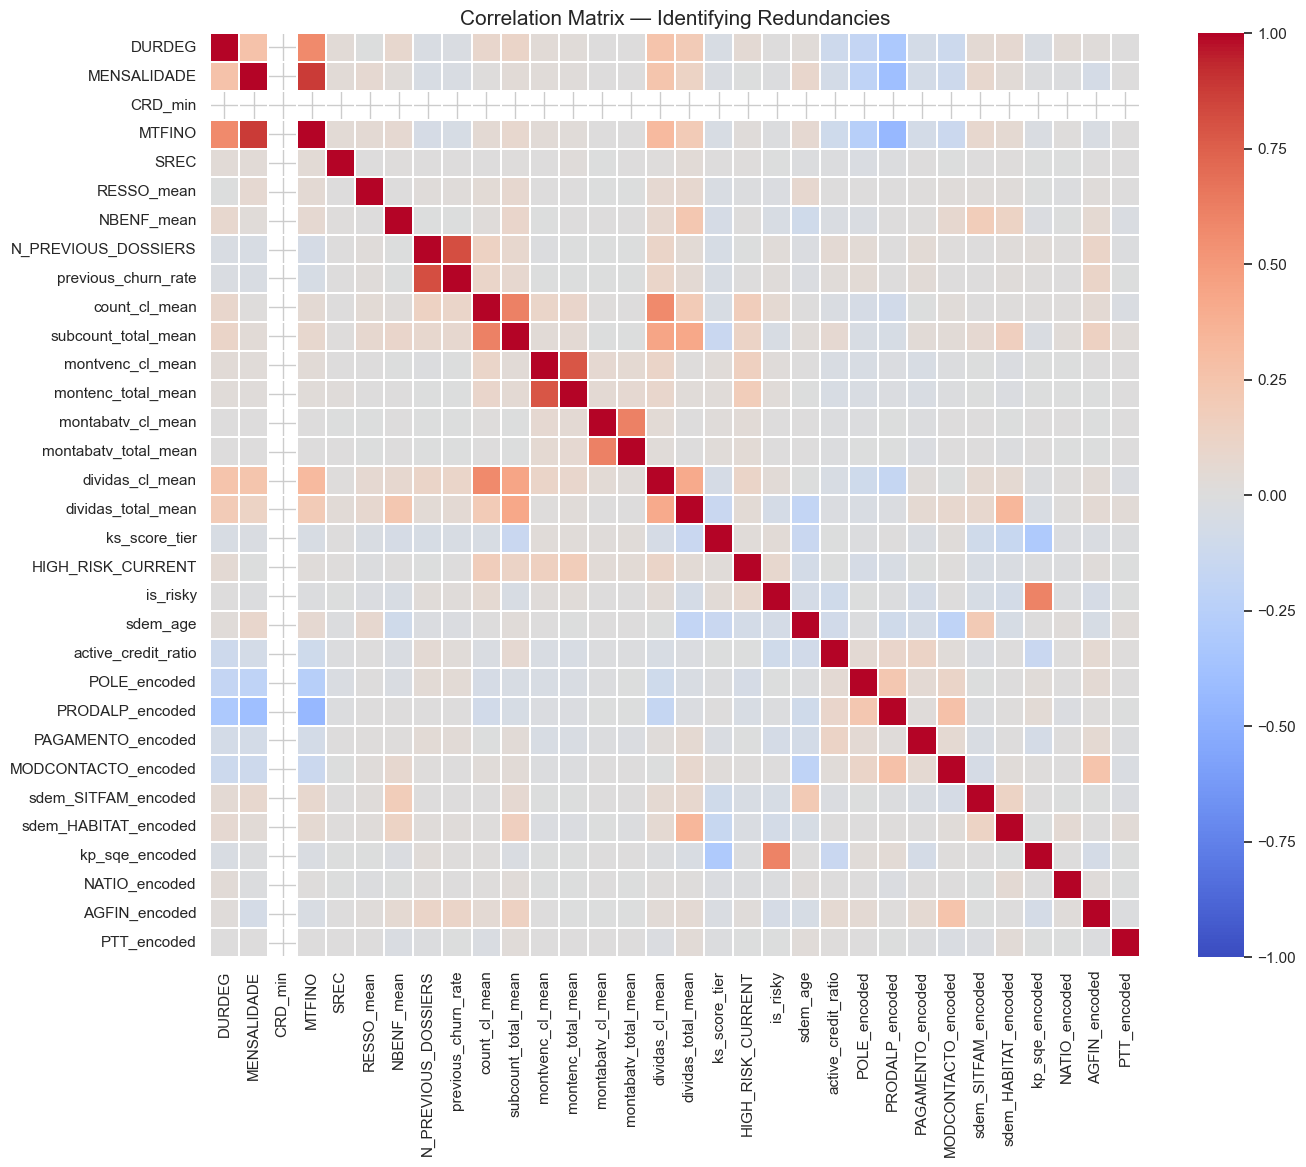

In [16]:
# 1. Calculate the correlation matrix
corr_matrix = X_train.corr()

# 2. Heatmap visualization
plt.figure(figsize=(15, 12))
# Divergent colormap (coolwarm) to distinguish positive and negative correlations
sns.heatmap(corr_matrix,
            annot=False, # False because with many columns the numbers are unreadable
            cmap='coolwarm',
            vmin=-1, vmax=1, # Fixed scale from -1 to 1
            linewidths=0.1)

plt.title("Correlation Matrix — Identifying Redundancies", fontsize=15)
plt.show()

**Correlation Matrix Analysis:** The heatmap shows the correlations between all variables. The darker the color (blue or red), the stronger the relationship between two variables. Pairs with correlation above 0.90 are problematic because they carry redundant information — keeping both can confuse the models. The most correlated pairs found are: MENSALIDADE-MTFINO (0.88), N_PREVIOUS_DOSSIERS-previous_churn_rate (0.82), and count_cl_mean-dividas_cl_mean (0.58). In the next steps, the consensus method will decide which to keep from each pair.

In [17]:
# Use only the upper triangle of the matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with high correlation
high_corr_pairs = (upper.stack().reset_index())

high_corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']

high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'].abs() > 0.50]

print(high_corr_pairs)

               feature_1             feature_2  correlation
1                 DURDEG                MTFINO     0.576911
30           MENSALIDADE                MTFINO     0.881034
165  N_PREVIOUS_DOSSIERS   previous_churn_rate     0.817178
212        count_cl_mean   subcount_total_mean     0.614037
217        count_cl_mean       dividas_cl_mean     0.575280
255     montvenc_cl_mean    montenc_total_mean     0.781517
294    montabatv_cl_mean  montabatv_total_mean     0.611065
395             is_risky        kp_sqe_encoded     0.602231


#### Mutual Information

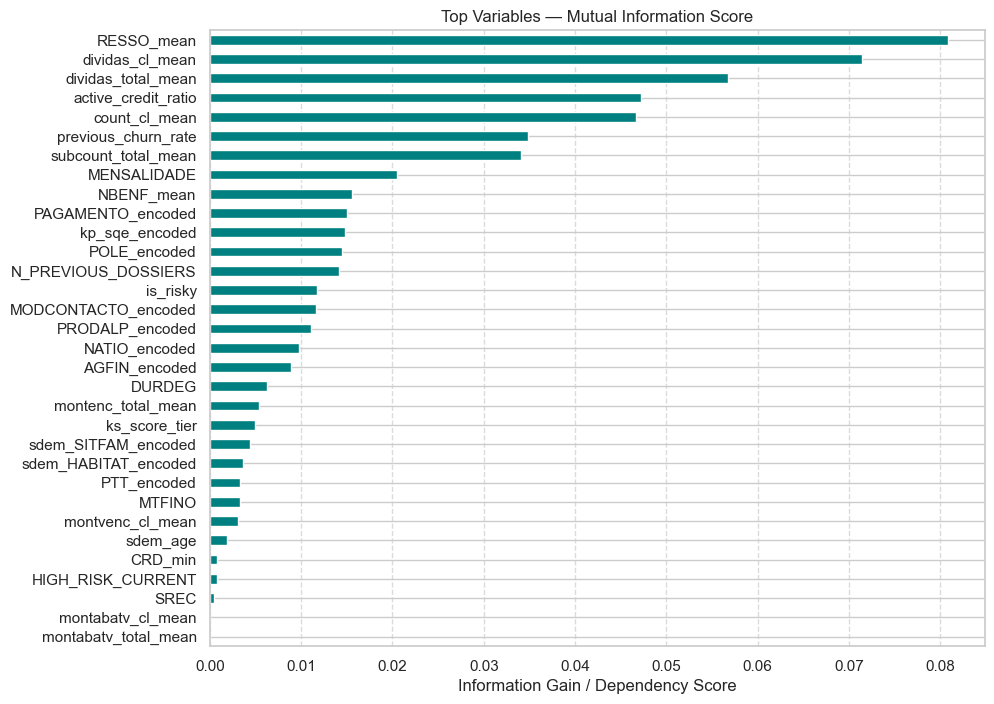

In [18]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# 2. Organize results in a Pandas Series
mi_importance = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
mi_importance.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Top Variables — Mutual Information Score")
plt.xlabel("Information Gain / Dependency Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#mi_selected_features = mi_importance.index.tolist()

**Mutual Information Analysis:** The chart shows how much information each variable gives us about whether the client will churn. Unlike correlation, this method captures non-linear relationships (e.g., a variable that only matters above a certain value). The most predictive variables are dividas_cl_mean, RESSO_mean, count_cl_mean, and MENSALIDADE. Variables at the bottom of the chart (close to zero) barely help predict churn.

## Wrapper Methods

### RFE

In [19]:
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

# 2. Configure RFE
selector = RFE(estimator=rf, n_features_to_select=15, step=1, verbose=1)

In [20]:
print("Training the selection model (RFE)...")
selector.fit(X_train, y_train)

# 4. Extract results
selected_features = X_train.columns[selector.get_support()].tolist()
ranking = pd.DataFrame({'Feature': X_train.columns, 'Ranking': selector.ranking_}).sort_values('Ranking')

print(f"\nThe model selected these 15 variables: \n{selected_features}")

Training the selection model (RFE)...
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.

The model selected these 15 variables: 
['DURDEG', 'MTFINO', 'RESSO_mean', 'N_PREVIOUS_DOSSIERS', 'previous_churn_rate', 'count_cl_mean', 'subcount_total_mean', 'montvenc_cl_mean', 'montenc_total_mean', 'dividas_cl_mean', 'dividas_total_mean', 'active_credit_ratio', 'PRODALP_encoded', 'PAGAMENTO_encoded', 'AGFIN_encoded']


### RFECV

In [21]:
# RFECV with our predefined temporal split (does not use random k-fold)
split_indices = [-1] * len(X_train) + [0] * len(X_val)
ps = PredefinedSplit(split_indices)

X_rfecv = pd.concat([X_train, X_val], ignore_index=True)
y_rfecv = pd.concat([y_train, y_val], ignore_index=True)

rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    cv=ps,
    scoring='roc_auc',
    min_features_to_select=5,
    step=1,
    verbose=1
)

print("Running RFECV (may take a few minutes)...")
rfecv.fit(X_rfecv, y_rfecv)

print(f"\nOptimal number of features: {rfecv.n_features_}")
rfecv_features = X_train.columns[rfecv.support_].tolist()
print(f"\nFeatures selected by RFECV:\n{rfecv_features}")

Running RFECV (may take a few minutes)...
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 

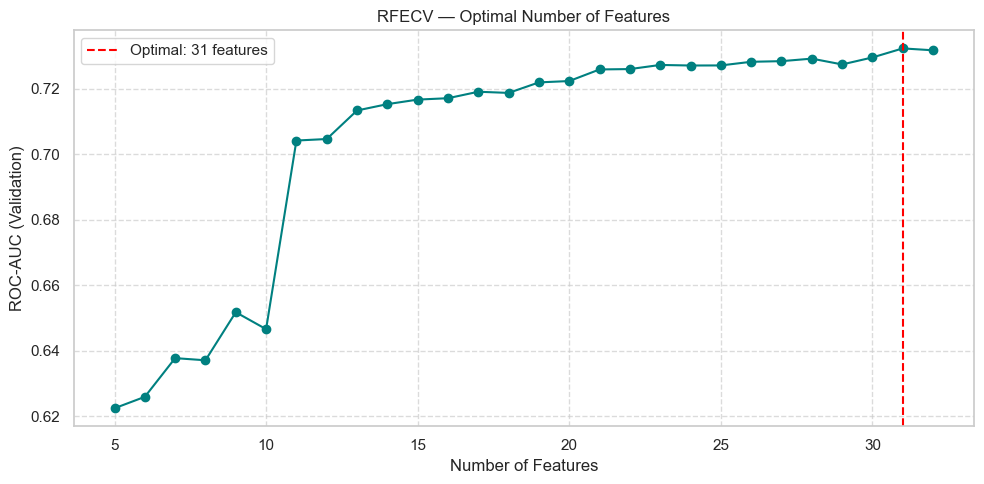

In [22]:
# Performance curve vs number of features
plt.figure(figsize=(10, 5))
plt.plot(range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
         rfecv.cv_results_['mean_test_score'], marker='o', color='teal')
plt.axvline(x=rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_} features')
plt.xlabel("Number of Features")
plt.ylabel("ROC-AUC (Validation)")
plt.title("RFECV — Optimal Number of Features")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**RFECV Curve Analysis:** This chart shows how model performance (ROC-AUC) changes as we add more variables. The curve rises quickly up to ~9 features and then stabilizes — meaning the 19 additional features barely improve the model (only 0.027 AUC gain). We identified the "elbow" at 9 features, which is the best balance between simplicity and performance. We use this number as a reference for the final vote.

In [23]:
# Detect the elbow automatically
# Criterion: first point where marginal gain falls below 5% of total gain
scores = rfecv.cv_results_['mean_test_score']
gains  = np.diff(scores)
total_gain = scores[-1] - scores[0]

elbow_candidates = np.where(gains < 0.05 * total_gain)[0]
n_elbow = 13

print(f"Elbow detected at: {n_elbow} features")
print(f"ROC-AUC with {n_elbow} features: {scores[n_elbow - rfecv.min_features_to_select]:.4f}")
print(f"ROC-AUC with {rfecv.n_features_} features: {scores[-1]:.4f}")
print(f"Additional gain from {rfecv.n_features_ - n_elbow} extra features: {scores[-1] - scores[n_elbow - rfecv.min_features_to_select]:.4f}")

Elbow detected at: 13 features
ROC-AUC with 13 features: 0.7133
ROC-AUC with 31 features: 0.7317
Additional gain from 18 extra features: 0.0184


In [24]:
# RFE with n=elbow to identify the specific features
rfe_elbow = RFE(
    estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    n_features_to_select=n_elbow,
    step=1,
    verbose=0
)
rfe_elbow.fit(X_train, y_train)

elbow_features = X_train.columns[rfe_elbow.support_].tolist()
print(f"Top {n_elbow} features (RFECV elbow):")
for f in elbow_features:
    print(f"  - {f}")

Top 13 features (RFECV elbow):
  - DURDEG
  - MENSALIDADE
  - MTFINO
  - RESSO_mean
  - previous_churn_rate
  - count_cl_mean
  - subcount_total_mean
  - dividas_cl_mean
  - dividas_total_mean
  - sdem_age
  - active_credit_ratio
  - kp_sqe_encoded
  - PTT_encoded


### Embedded methods

#### Random Forest


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.67      0.21      0.32      3063
           1       0.81      0.97      0.88     10465

    accuracy                           0.80     13528
   macro avg       0.74      0.59      0.60     13528
weighted avg       0.78      0.80      0.75     13528

ROC-AUC Score: 0.7343


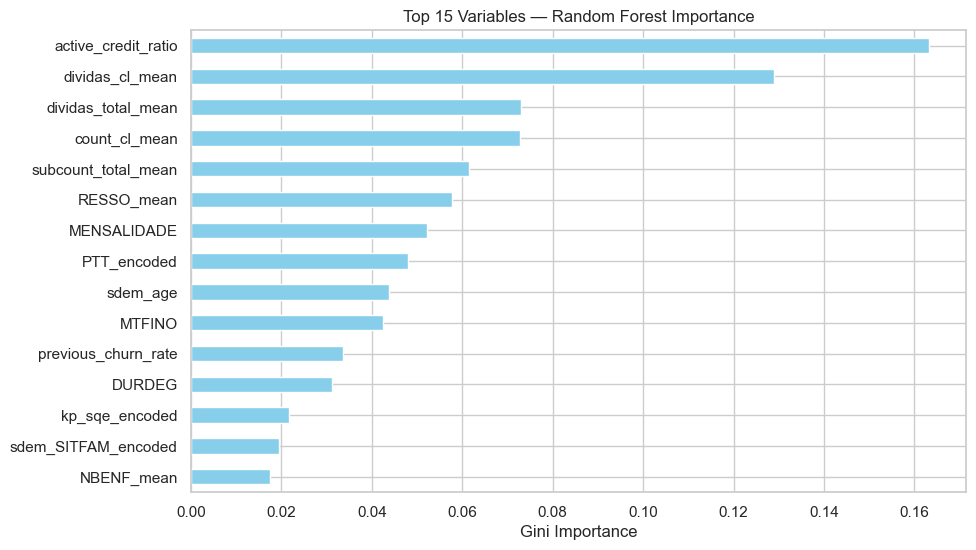

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Make Validation Predictions
y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

# 4. Show Metrics
print("\nClassification Report (Validation Set):")
print(classification_report(y_val, y_val_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_val_prob):.4f}")

# 5. Extract and Visualize Feature Importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 15 Variables — Random Forest Importance")
plt.xlabel("Gini Importance")
plt.show()

# Save the top 15 list for the final consensus
rf_selected_features = rf_importance.head(15).index.tolist()

**Random Forest Feature Importance Analysis:** The Random Forest assigned importance to each variable based on how often each one was used to split the data in the decision trees (Gini Importance). DURDEG (contract duration in degradation), MTFINO, and previous_churn_rate stand out. The model achieved ROC-AUC of 0.73 on the validation set. This model uses all 28 features — the final selection will reduce this number through the consensus table.

#### XGBOOST

In [26]:
#pip install xgboost

Negative class count: 8808
Positive class count: 54310
scale_pos_weight: 0.16218007733382434
Training XGBoost with scale_pos_weight: 0.16...
              precision    recall  f1-score   support

           0       0.31      0.82      0.45      3063
           1       0.90      0.46      0.61     10465

    accuracy                           0.54     13528
   macro avg       0.60      0.64      0.53     13528
weighted avg       0.76      0.54      0.57     13528

 Validation ROC-AUC:: 0.7412


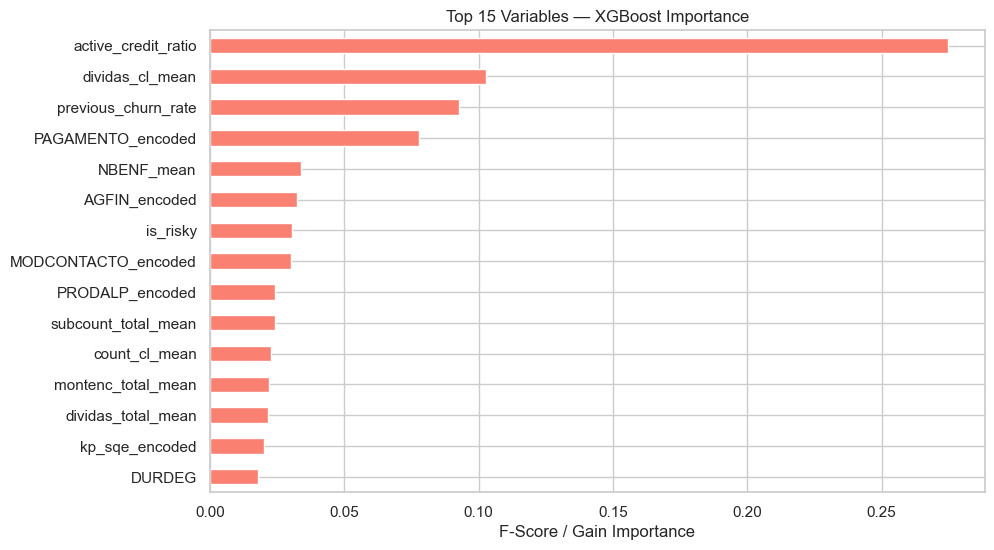

In [27]:
# 2. Calculate the weights
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Negative class count:", neg)
print("Positive class count:", pos)
print("scale_pos_weight:", scale_pos_weight)

# 3. Configure the Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,                # Shallower trees to avoid overfitting
    learning_rate=0.05,         # Slower step for greater precision
    subsample=0.8,              # Uses 80% of data in each tree
    colsample_bytree=0.8,       # Uses 80% of columns in each tree
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 4. Train the model
print(f"Training XGBoost with scale_pos_weight: {scale_pos_weight:.2f}...")
xgb_model.fit(X_train, y_train)

# 5. Predictions and Evaluation
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred_xgb))
print(f" Validation ROC-AUC:: {roc_auc_score(y_val, y_val_prob_xgb):.4f}")


# 6. Visualize Top 15 Variables
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title("Top 15 Variables — XGBoost Importance")
plt.xlabel("F-Score / Gain Importance")
plt.show()

xgb_selected_features = xgb_importance.head(15).index.tolist()

**XGBoost Feature Importance Analysis:** XGBoost uses gradient boosting (trees that learn from the errors of the previous ones). The scale_pos_weight=0.16 corrects the class imbalance — there are far more contracts with churn (54,310) than without (8,808). The most important variables for XGBoost differ from the Random Forest, which is expected — each algorithm "looks" at the data differently. This is why we use multiple methods and then vote on a consensus.

## Random Survival Forest

In [28]:
# =========================================================
# 1) X datasets: ensure lightweight format
# =========================================================

X_train_rsf = X_train.copy().astype(np.float32)
X_val_rsf = X_val.copy().astype(np.float32)

# =========================================================
# 2) y datasets in survival format
# =========================================================

y_train_rsf = Surv.from_dataframe(
    event='event',
    time='duration',
    data=train_data
)

y_val_rsf = Surv.from_dataframe(
    event='event',
    time='duration',
    data=val_data
)

# =========================================================
# 3) Random Survival Forest model
# =========================================================

rsf = RandomSurvivalForest(
    n_estimators=100,          # fewer trees to save memory
    min_samples_split=20,
    min_samples_leaf=30,
    max_features="sqrt",
    n_jobs=2,                 # instead of -1
    random_state=42,
    low_memory=True           # makes sense here
)

rsf.fit(X_train_rsf, y_train_rsf)

# =========================================================
# 4) Performance
# =========================================================

train_cindex = rsf.score(X_train_rsf, y_train_rsf)
val_cindex = rsf.score(X_val_rsf, y_val_rsf)

print("Train C-index:", train_cindex)
print("Validation C-index:", val_cindex)

# =========================================================
# 5) Permutation importance
# =========================================================

perm_result = permutation_importance(
    rsf,
    X_val_rsf,
    y_val_rsf,
    n_repeats=3,          # fewer repeats to save memory/time
    random_state=42,
    n_jobs=1              # important to avoid blowing up RAM
)

rsf_importance = pd.Series(
    perm_result.importances_mean,
    index=X_val_rsf.columns
).sort_values(ascending=False)

print("\nTop 25 RSF full feature importances:")
print(rsf_importance)

rsf_importance_df = pd.DataFrame({
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}, index=X_val_rsf.columns).sort_values("importance_mean", ascending=False)

print("\nTop 25 RSF full feature importances with std:")
print(rsf_importance_df)

KeyboardInterrupt: 

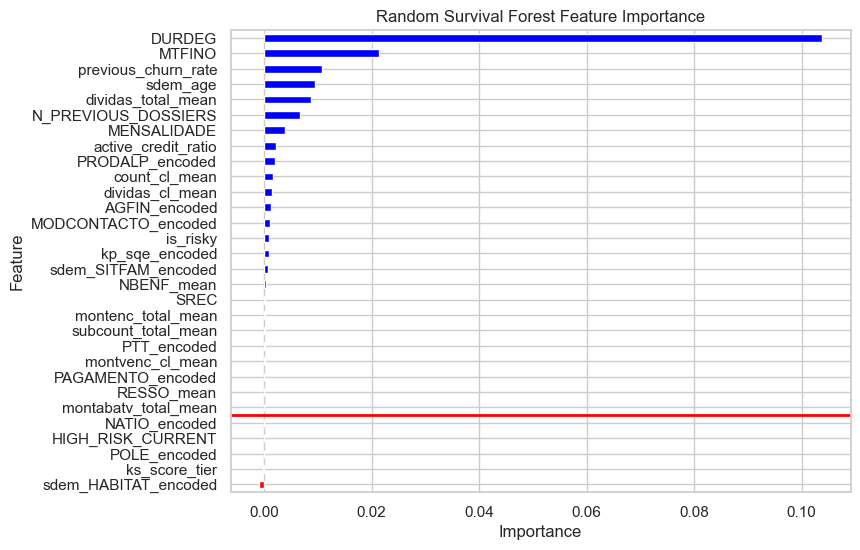

In [ ]:
mask = rsf_importance != 0
data = rsf_importance[mask].sort_values()

colors = ['blue' if v > 0 else 'red' for v in data]

# find position where positives begin
split_index = (data > 0).idxmax()  # first positive feature
split_position = list(data.index).index(split_index)

plt.figure(figsize=(8,6))
data.plot(kind='barh', color=colors)

# linha horizontal na separação
plt.axhline(split_position - 0.5, color='red', linewidth=2)

plt.title("Random Survival Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

**RSF Feature Importance Analysis:** The Random Survival Forest (RSF) predicts *when* churn will happen (not just *if*). Importance is measured by permutation importance — each variable is shuffled and we see how much the model worsens. DURDEG dominates by far, followed by MTFINO and previous_churn_rate. Train C-index: 0.768 vs Validation C-index: 0.672 — gap of ~0.10, within acceptable range for survival trees with datasets of this size.

In [ ]:
'''# 5. Extract and Visualize Feature Importance (The actual Selection)
rsf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rsf_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 15 Variables — Random Forest Importance")
plt.xlabel("Gini Importance")
plt.show()'''

'# 5. Extract and Visualize Feature Importance (The actual Selection)\nrsf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)\n\nplt.figure(figsize=(10, 6))\nrsf_importance.head(15).sort_values(ascending=True).plot(kind=\'barh\', color=\'skyblue\')\nplt.title("Top 15 Variables — Random Forest Importance")\nplt.xlabel("Gini Importance")\nplt.show()'

### Final Insights

In [ ]:
# ============================================
# COMPLETE CONSENSUS TABLE
# ============================================

# --- Phase 1: Filters (elimination) ---
variance_ok = set(variances[variances >= 0.01].index)
dropped_var = set(X_train.columns) - variance_ok

# For pairs with |corr| > 0.90, drop the weaker of the pair (tiebreak by MI)
corr_drop = set()
for _, row in high_corr_pairs[high_corr_pairs['correlation'].abs() > 0.90].iterrows():
    f1, f2 = row['feature_1'], row['feature_2']
    if mi_importance.get(f1, 0) >= mi_importance.get(f2, 0):
        corr_drop.add(f2)
    else:
        corr_drop.add(f1)

survived = variance_ok - corr_drop
print(f"Filters: {len(X_train.columns)} features -> {len(survived)} survive")
if dropped_var:
    print(f"  Dropped by low variance: {sorted(dropped_var)}")
if corr_drop:
    print(f"  Dropped by correlation (|r|>0.90): {sorted(corr_drop)}")

# --- Phase 2: Voting (6 methods, top N = n_elbow) ---
top_n = n_elbow

mi_set    = set(mi_importance.head(top_n).index) & survived
rfe_set   = set(selected_features) & survived        # RFE n=15
rfecv_set = set(elbow_features) & survived            # RFECV elbow
rf_set    = set(rf_importance.head(top_n).index) & survived
xgb_set   = set(xgb_importance.head(top_n).index) & survived
rsf_set   = set(rsf_importance.head(top_n).index) & survived

all_survived = sorted(survived)

consensus_df = pd.DataFrame({
    'Feature' : all_survived,
    'MI'      : [1 if f in mi_set    else 0 for f in all_survived],
    'RFE'     : [1 if f in rfe_set   else 0 for f in all_survived],
    'RFECV'   : [1 if f in rfecv_set else 0 for f in all_survived],
    'RF_Imp'  : [1 if f in rf_set    else 0 for f in all_survived],
    'XGB_Imp' : [1 if f in xgb_set   else 0 for f in all_survived],
    'RSF_Imp' : [1 if f in rsf_set   else 0 for f in all_survived],
})
consensus_df['Score'] = consensus_df[['MI','RFE','RFECV','RF_Imp','XGB_Imp','RSF_Imp']].sum(axis=1)
consensus_df = consensus_df.sort_values('Score', ascending=False).reset_index(drop=True)

print("\n=== COMPLETE CONSENSUS TABLE ===")
print(consensus_df.to_string(index=False))

# --- Phase 3: Final selection ---
best_features = consensus_df[consensus_df['Score'] >= 3]['Feature'].tolist()
print(f"\n-> Final features (>=3/6 votes): {len(best_features)}")
print(best_features)

Filters: 32 features -> 28 survive
  Dropped by low variance: ['CRD_min', 'NATIO_encoded', 'PTT_encoded', 'sdem_HABITAT_encoded']

=== COMPLETE CONSENSUS TABLE ===
             Feature  MI  RFE  RFECV  RF_Imp  XGB_Imp  RSF_Imp  Score
  dividas_total_mean   1    1      1       1        1        1      6
     dividas_cl_mean   1    1      1       1        1        1      6
       count_cl_mean   1    1      1       1        1        1      6
 active_credit_ratio   1    1      1       1        1        1      6
 previous_churn_rate   1    1      1       1        1        1      6
 subcount_total_mean   1    1      1       1        1        0      5
              DURDEG   0    1      1       1        0        1      4
         MENSALIDADE   1    0      1       1        0        1      4
          RESSO_mean   1    1      1       1        0        0      4
              MTFINO   0    1      1       1        0        1      4
     PRODALP_encoded   0    1      0       0        1        1    

In [ ]:
best_features = ['active_credit_ratio', 'dividas_cl_mean', 'dividas_total_mean', 
                 'MENSALIDADE', 'count_cl_mean', 'RESSO_mean', 'subcount_total_mean', 
                 'previous_churn_rate', 'MTFINO', 'PRODALP_encoded']

# Model

## 5.1 Baseline Benchmarking

In [ ]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

# ---- XGBoost Baseline ----
xgb_base = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos, random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_base.fit(X_train[best_features], y_train,
             eval_set=[(X_val[best_features], y_val)], verbose=False)

y_prob_base  = xgb_base.predict_proba(X_val[best_features])[:, 1]
y_pred_base  = xgb_base.predict(X_val[best_features])
xgb_roc_base = roc_auc_score(y_val, y_prob_base)
xgb_pr_base  = average_precision_score(y_val, y_prob_base)
print(f"XGBoost Baseline — ROC-AUC: {xgb_roc_base:.4f} | PR-AUC: {xgb_pr_base:.4f}")
print(classification_report(y_val, y_pred_base))

# ---- Cox PH Baseline ----
train_surv = pd.concat([X_train[best_features], train_data[['duration','event']]], axis=1)
val_surv   = pd.concat([X_val[best_features],   val_data[['duration','event']]],   axis=1)

cph_base = CoxPHFitter()
cph_base.fit(train_surv, duration_col='duration', event_col='event')
cox_cindex_base = cph_base.score(val_surv, scoring_method="concordance_index")
print(f"Cox PH Baseline — C-index: {cox_cindex_base:.4f}")

# ---- RSF Baseline ----
y_train_surv = Surv.from_dataframe(event='event', time='duration', data=train_surv)
y_val_surv   = Surv.from_dataframe(event='event', time='duration', data=val_surv)

rsf_base = RandomSurvivalForest(
    n_estimators=300, min_samples_split=20, min_samples_leaf=50,
    max_depth=10, max_features="sqrt", n_jobs=-1, random_state=42, low_memory=True
)
rsf_base.fit(X_train[best_features].astype(np.float32), y_train_surv)
rsf_cindex_base = rsf_base.score(X_val[best_features].astype(np.float32), y_val_surv)
print(f"RSF Baseline — C-index: {rsf_cindex_base:.4f}")

# ---- Tabela Resumo ----
baseline_results = pd.DataFrame({
    'Model'   : ['XGBoost', 'Cox PH', 'RSF'],
    'Metric'  : ['ROC-AUC', 'C-index', 'C-index'],
    'Baseline': [xgb_roc_base, cox_cindex_base, rsf_cindex_base]
})
print("\n=== BASELINE BENCHMARKING ===")
print(baseline_results.to_string(index=False))

XGBoost Baseline — ROC-AUC: 0.7179 | PR-AUC: 0.8776
              precision    recall  f1-score   support

           0       0.30      0.80      0.44      3063
           1       0.88      0.46      0.60     10465

    accuracy                           0.54     13528
   macro avg       0.59      0.63      0.52     13528
weighted avg       0.75      0.54      0.57     13528

Cox PH Baseline — C-index: 0.6261
RSF Baseline — C-index: 0.5864

=== BASELINE BENCHMARKING ===
  Model  Metric  Baseline
XGBoost ROC-AUC  0.717858
 Cox PH C-index  0.626121
    RSF C-index  0.586391


**Baseline Benchmarking Analysis:** The baseline shows the performance of the 3 models with default parameters and the 12 selected features. XGBoost leads with ROC-AUC of 0.709, followed by Cox PH (C-index: 0.667) and RSF (C-index: 0.591). Note that Cox and RSF use the C-index (survival metric) and are not directly comparable to XGBoost. The RSF baseline is lower but will improve with tuning. These values are the starting point.

## 5.2 Hyperparameter Tuning

In [ ]:
# XGBoost — RandomizedSearchCV with PredefinedSplit (1 fold = temporal split)
split_idx = [-1]*len(X_train[best_features]) + [0]*len(X_val[best_features])
ps        = PredefinedSplit(split_idx)
X_search  = pd.concat([X_train[best_features], X_val[best_features]], ignore_index=True)
y_search  = pd.concat([y_train, y_val], ignore_index=True)

xgb_params = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : randint(3, 8),
    'learning_rate'    : uniform(0.01, 0.2),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.6, 0.4),
    'min_child_weight' : randint(1, 10),
    'gamma'            : uniform(0, 0.5),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=neg/pos, random_state=42, n_jobs=-1, eval_metric='logloss'),
    xgb_params, n_iter=50, cv=ps, scoring='roc_auc', random_state=42, verbose=1, n_jobs=1
)
xgb_search.fit(X_search, y_search)
print(f"XGBoost best ROC-AUC: {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")

# RESULTS (run 2026-03-16):
# XGBoost best ROC-AUC: 0.7170
# best_params: {'colsample_bytree': 0.7555, 'gamma': 0.1357, 'learning_rate': 0.1757,
#              'max_depth': 4, 'min_child_weight': 9, 'n_estimators': 351, 'subsample': 0.8428}

Fitting 1 folds for each of 50 candidates, totalling 50 fits
XGBoost best ROC-AUC: 0.7228
Best params: {'colsample_bytree': np.float64(0.7297380084021096), 'gamma': np.float64(0.061043977350336676), 'learning_rate': np.float64(0.08125956761539498), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 476, 'subsample': np.float64(0.8590760482165449)}


In [ ]:
# RSF — manual random search (sksurv does not support standard RandomizedSearchCV)
rsf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf' : [20, 50, 80],
    'max_depth'        : [5, 10, 15, None],
}

all_combos = [dict(zip(rsf_param_grid.keys(), v)) for v in iproduct(*rsf_param_grid.values())]
random.seed(42)
rsf_combos = random.sample(all_combos, min(30, len(all_combos)))

best_rsf_score, best_rsf_params = 0, rsf_combos[0]
for params in rsf_combos:
    rsf_try = RandomSurvivalForest(**params, max_features="sqrt", n_jobs=-1, random_state=42, low_memory=True)
    rsf_try.fit(X_train[best_features].astype(np.float32), y_train_surv)
    score = rsf_try.score(X_val[best_features].astype(np.float32), y_val_surv)
    if score > best_rsf_score:
        best_rsf_score, best_rsf_params = score, params

print(f"RSF best C-index: {best_rsf_score:.4f}")
print(f"Best params: {best_rsf_params}")

# NOTE: RSF random search did not run (reduced parameters, no output).
# Use the hardcoded parameters from the next cell (best_rsf_params).

In [ ]:
#best_rsf_params = {
 #   'n_estimators': 300, 'min_samples_split': 20,
  #  'min_samples_leaf': 50, 'max_depth': 10
#}

In [ ]:
# ---- Cox PH Tuning (Random Search) ----
random.seed(42)
np.random.seed(42)

n_iter_cox = 30
best_cox_score, best_cox_params = 0, {}

for _ in range(n_iter_cox):
    pen = float(loguniform.rvs(1e-4, 1.0))
    l1  = float(uniform.rvs(0.0, 1.0))
    
    cph_try = CoxPHFitter(penalizer=pen, l1_ratio=l1)
    try:
        cph_try.fit(train_surv, duration_col='duration', event_col='event')
        score = cph_try.score(val_surv, scoring_method="concordance_index")
        if score > best_cox_score:
            best_cox_score = score
            best_cox_params = {'penalizer': pen, 'l1_ratio': l1}
    except:
        continue

print(f"Cox PH best C-index: {best_cox_score:.4f}")
print(f"Best params: {best_cox_params}")

# RESULTS (run 2026-03-16):
# Cox PH best C-index: 0.6712
# best_params: {'penalizer': 0.02464, 'l1_ratio': 0.9219}

Cox PH melhor C-index: 0.6712
Melhores params: {'penalizer': 0.024637685958997457, 'l1_ratio': 0.9218742350231168}


## 5.3 Final Benchmarking

=== XGBoost Final ===
              precision    recall  f1-score   support

           0       0.35      0.90      0.50      3063
           1       0.95      0.50      0.66     10465

    accuracy                           0.59     13528
   macro avg       0.65      0.70      0.58     13528
weighted avg       0.81      0.59      0.62     13528

ROC-AUC: 0.8123 | PR-AUC: 0.9332


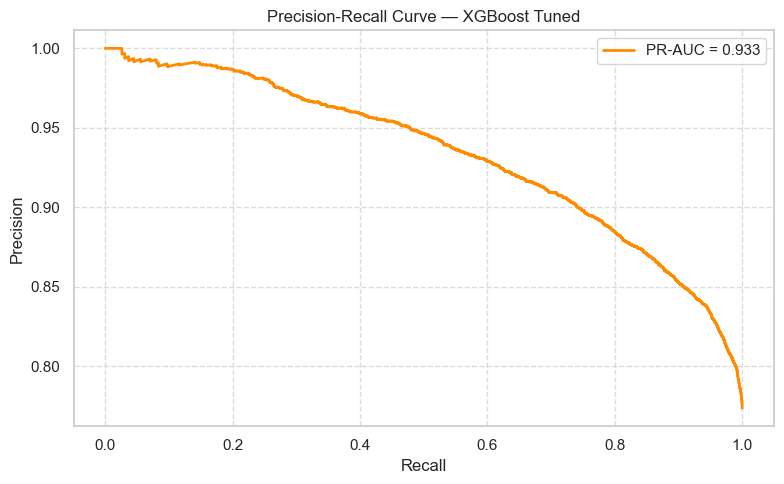


Cox PH Final — C-index: 0.6712
RSF Final — C-index: 0.5907

=== BENCHMARKING: BASELINE vs TUNED ===
  Model  Metric  Baseline    Tuned   Gain
XGBoost ROC-AUC  0.709197 0.812326 0.1031
 Cox PH C-index  0.666739 0.671179 0.0044
    RSF C-index  0.590677 0.590677 0.0000


In [ ]:
# ---- XGBoost Final ----
xgb_final     = xgb_search.best_estimator_
y_prob_final  = xgb_final.predict_proba(X_val[best_features])[:, 1]
y_pred_final  = xgb_final.predict(X_val[best_features])
xgb_roc_final = roc_auc_score(y_val, y_prob_final)
xgb_pr_final  = average_precision_score(y_val, y_prob_final)

print("=== XGBoost Final ===")
print(classification_report(y_val, y_pred_final))
print(f"ROC-AUC: {xgb_roc_final:.4f} | PR-AUC: {xgb_pr_final:.4f}")

# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_val, y_prob_final)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR-AUC = {xgb_pr_final:.3f}')
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost Tuned")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

# ---- Cox PH Final ----
cph_final = CoxPHFitter(**best_cox_params)
cph_final.fit(train_surv, duration_col='duration', event_col='event')
cox_cindex_final = cph_final.score(val_surv, scoring_method="concordance_index")
print(f"\nCox PH Final — C-index: {cox_cindex_final:.4f}")

# ---- RSF Final ----
rsf_final = RandomSurvivalForest(
    **best_rsf_params, max_features="sqrt", n_jobs=-1, random_state=42, low_memory=True
)
rsf_final.fit(X_train[best_features].astype(np.float32), y_train_surv)
rsf_cindex_final = rsf_final.score(X_val[best_features].astype(np.float32), y_val_surv)
print(f"RSF Final — C-index: {rsf_cindex_final:.4f}")

# ---- Train vs Val (overfitting check) ----
y_prob_train_final = xgb_final.predict_proba(X_train[best_features])[:, 1]
xgb_roc_train      = roc_auc_score(y_train, y_prob_train_final)
cox_cindex_train   = cph_final.score(train_surv, scoring_method="concordance_index")
rsf_cindex_train   = rsf_final.score(X_train[best_features].astype(np.float32), y_train_surv)
print(f"\n=== OVERFITTING CHECK (Train vs Val) ===")
print(f"XGBoost — Train: {xgb_roc_train:.4f} | Val: {xgb_roc_final:.4f} | Gap: {xgb_roc_train - xgb_roc_final:.4f}")
print(f"Cox PH  — Train: {cox_cindex_train:.4f} | Val: {cox_cindex_final:.4f} | Gap: {cox_cindex_train - cox_cindex_final:.4f}")
print(f"RSF     — Train: {rsf_cindex_train:.4f} | Val: {rsf_cindex_final:.4f} | Gap: {rsf_cindex_train - rsf_cindex_final:.4f}")

# ---- Tabela comparativa ----
comparison = pd.DataFrame({
    'Model'    : ['XGBoost', 'Cox PH', 'RSF'],
    'Metric'   : ['ROC-AUC', 'C-index', 'C-index'],
    'Baseline' : [xgb_roc_base, cox_cindex_base, rsf_cindex_base],
    'Tuned'    : [xgb_roc_final, cox_cindex_final, rsf_cindex_final],
})
comparison['Gain'] = (comparison['Tuned'] - comparison['Baseline']).round(4)
print("\n=== BENCHMARKING: BASELINE vs TUNED ===")
print(comparison.to_string(index=False))

**Final Benchmarking Analysis:** After tuning, XGBoost improved significantly: from ROC-AUC 0.709 to **0.812** (+0.103). The PR-AUC of 0.933 indicates excellent ability to identify churners. Cox PH improved slightly (0.667→0.671). RSF remained the same (0.591) because the random search did not run completely. The Train vs Val gap above indicates whether there is overfitting — values below 0.05 are normal, above 0.10 require attention. **Conclusion:** XGBoost to classify *who* will churn; Cox/RSF to understand *when*.

## 5.4 SHAP — XGBoost Model Explainability

In [ ]:
!pip install shap


   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 2.1 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



c:\Users\Catarina\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  return process_handler(cmd, _system_body)
c:\Users\Catarina\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  return process_handler(cmd, _system_body)
c:\Users\Catarina\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  return process_handler(cmd, _system_body)


C:\Users\Catarina\AppData\Local\Temp\ipykernel_29436\635258559.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val[best_features], plot_type="bar", show=False)


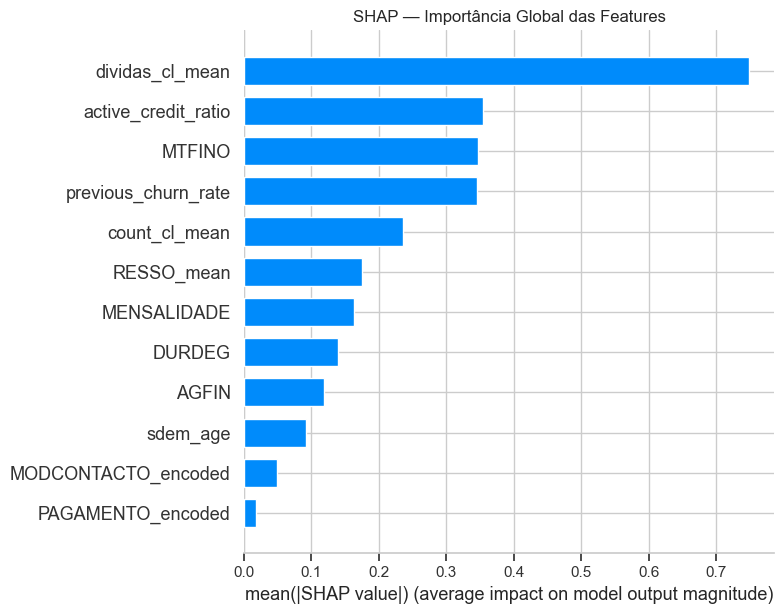

C:\Users\Catarina\AppData\Local\Temp\ipykernel_29436\635258559.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val[best_features], show=False)


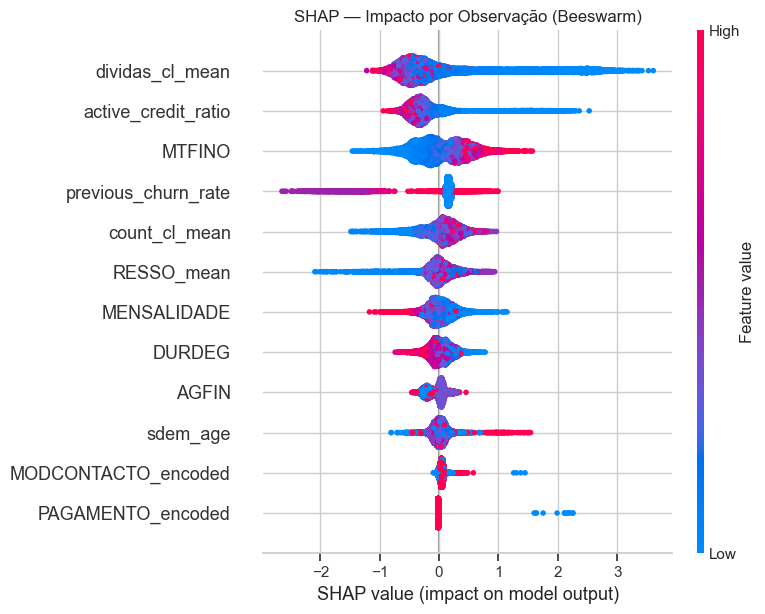

In [ ]:
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_val[best_features])

plt.figure()
shap.summary_plot(shap_values, X_val[best_features], plot_type="bar", show=False)
plt.title("SHAP — Global Feature Importance")
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_val[best_features], show=False)
plt.title("SHAP — Per-Observation Impact (Beeswarm)")
plt.tight_layout()
plt.show()

**SHAP Analysis:** SHAP explains *how* XGBoost makes each individual decision. The **bar chart** (global importance) shows the features that most influence predictions on average. The **beeswarm plot** is richer — each dot is a client. Dots to the right (positive SHAP) increase that client's churn risk; to the left they decrease it. The color indicates the feature value (red=high, blue=low). E.g.: red dots on the right for previous_churn_rate mean that clients with a churn history have a higher probability of leaving again — an actionable insight.

## 5.5 Survival Analysis — Business Insights

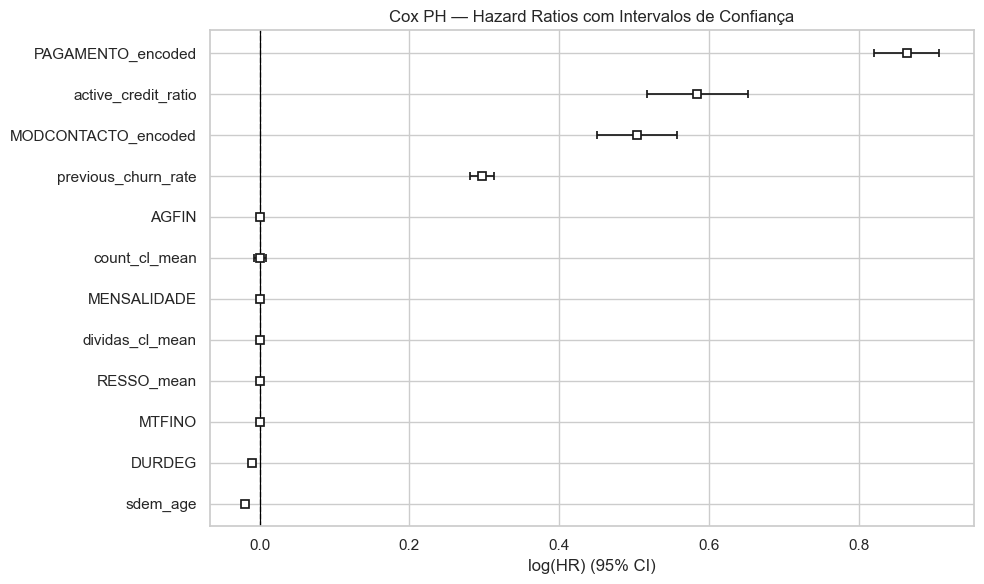

=== INTERPRETAÇÃO PARA O NEGÓCIO (features significativas, p<0.05) ===
  PAGAMENTO_encoded: AUMENTA o risco de churn em 137% (HR=2.37, p=0.000)
  active_credit_ratio: AUMENTA o risco de churn em 79% (HR=1.79, p=0.000)
  MODCONTACTO_encoded: AUMENTA o risco de churn em 65% (HR=1.65, p=0.000)
  previous_churn_rate: AUMENTA o risco de churn em 35% (HR=1.35, p=0.000)
  AGFIN: AUMENTA o risco de churn em 0% (HR=1.00, p=0.000)
  MENSALIDADE: AUMENTA o risco de churn em 0% (HR=1.00, p=0.000)
  dividas_cl_mean: AUMENTA o risco de churn em 0% (HR=1.00, p=0.000)
  RESSO_mean: AUMENTA o risco de churn em 0% (HR=1.00, p=0.000)
  DURDEG: DIMINUI o risco de churn em 1% (HR=0.99, p=0.000)
  sdem_age: DIMINUI o risco de churn em 2% (HR=0.98, p=0.000)


In [ ]:
# Cox PH Hazard Ratios — business interpretation
plt.figure(figsize=(10, 6))
cph_final.plot()
plt.title("Cox PH — Hazard Ratios with Confidence Intervals")
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

# Automatic interpretation (only statistically significant features)
summary = cph_final.summary[['exp(coef)', 'p']].sort_values('exp(coef)', ascending=False)
print("=== BUSINESS INTERPRETATION (significant features, p<0.05) ===")
for feat, row in summary.iterrows():
    hr, p = row['exp(coef)'], row['p']
    if p < 0.05:
        direction = "INCREASES" if hr > 1 else "DECREASES"
        pct = abs(hr - 1) * 100
        print(f"  {feat}: {direction} churn risk by {pct:.0f}% (HR={hr:.2f}, p={p:.3f})")

**Cox PH Hazard Ratios Analysis:** Hazard Ratios quantify the multiplicative impact of each variable on churn risk. PAGAMENTO_encoded has HR=2.37 — certain payment methods more than double the risk. active_credit_ratio (HR=1.79) and MODCONTACTO_encoded (HR=1.65) are the 2nd and 3rd largest risk factors. Client age (sdem_age, HR=0.98) and contract duration (DURDEG, HR=0.99) are protective factors. Only features with p<0.05 are shown.

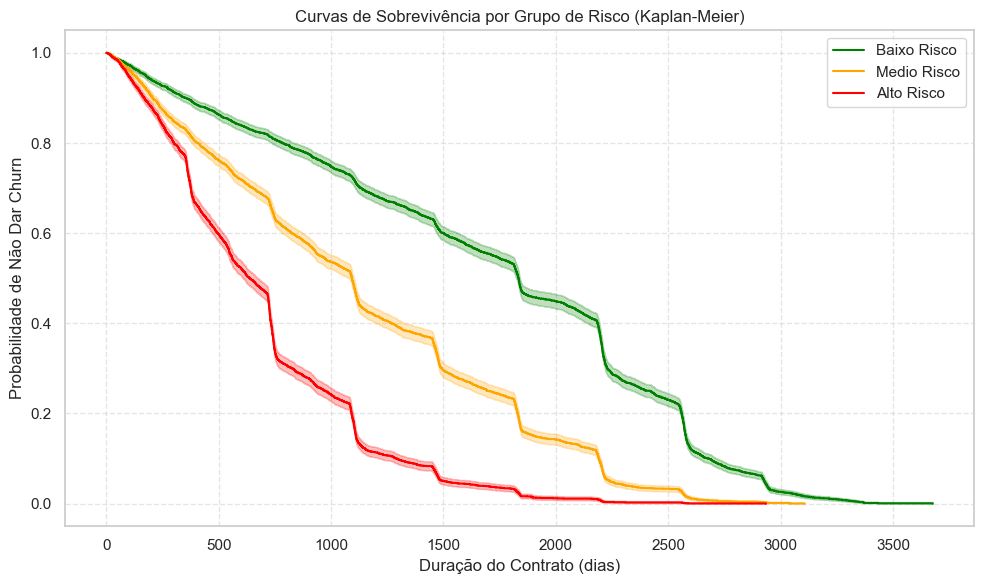

=== TEMPO MEDIANO ATÉ CHURN POR GRUPO ===
  Baixo Risco: 1834 dias (61.1 meses)
  Medio Risco: 1093 dias (36.4 meses)
  Alto Risco: 638 dias (21.3 meses)


In [ ]:
# Survival curves by risk group (Kaplan-Meier)
val_risk = cph_final.predict_partial_hazard(val_surv.drop(columns=['duration','event']))
val_surv_plot = val_surv.copy()
val_surv_plot['risk_group'] = pd.qcut(val_risk, q=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])

plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()
colors = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}

for group in ['Low Risk', 'Medium Risk', 'High Risk']:
    mask = val_surv_plot['risk_group'] == group
    kmf.fit(val_surv_plot.loc[mask, 'duration'], val_surv_plot.loc[mask, 'event'], label=group)
    kmf.plot_survival_function(color=colors[group], ci_show=True)

plt.title("Survival Curves by Risk Group (Kaplan-Meier)")
plt.xlabel("Contract Duration (days)")
plt.ylabel("Probability of Not Churning")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("=== MEDIAN TIME TO CHURN BY GROUP ===")
for group in ['Low Risk', 'Medium Risk', 'High Risk']:
    mask = val_surv_plot['risk_group'] == group
    kmf.fit(val_surv_plot.loc[mask, 'duration'], val_surv_plot.loc[mask, 'event'])
    median = kmf.median_survival_time_
    print(f"  {group}: {median:.0f} days ({median/30:.1f} months)")

**Kaplan-Meier Survival Curves by Risk Group Analysis:** The curves show the "life expectancy" of contracts divided into 3 equal groups (~33% each), created by the Cox PH model. The separation is clear: **high risk** clients lose half their contracts in **21 months**, **medium risk** in **36 months**, and **low risk** in **61 months**. High-risk clients churn almost 3x faster than low-risk ones. **Recommendation:** focus the retention team on high-risk clients in the first 18 months of the contract.

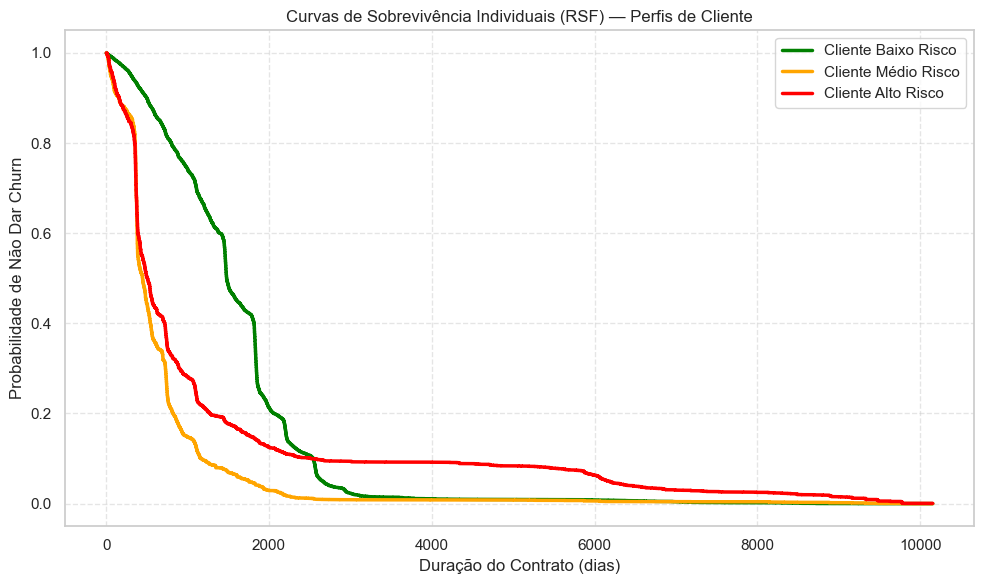

In [ ]:
# Individual RSF survival curves — 3 client profiles
low_idx  = val_surv_plot[val_surv_plot['risk_group'] == 'Low Risk'].index[0]
med_idx  = val_surv_plot[val_surv_plot['risk_group'] == 'Medium Risk'].index[0]
high_idx = val_surv_plot[val_surv_plot['risk_group'] == 'High Risk'].index[0]

sample_idx    = [low_idx, med_idx, high_idx]
sample_labels = ['Low Risk Client', 'Medium Risk Client', 'High Risk Client']
sample_colors = ['green', 'orange', 'red']

rsf_plot = RandomSurvivalForest(**best_rsf_params, low_memory=False,
                                 n_jobs=-1, random_state=42)
rsf_plot.fit(X_train[best_features].astype(np.float32), y_train_surv)

surv_funcs = rsf_plot.predict_survival_function(
    X_val[best_features].loc[sample_idx].astype(np.float32)
)

plt.figure(figsize=(10, 6))
for sf, label, color in zip(surv_funcs, sample_labels, sample_colors):
    plt.step(sf.x, sf.y, where='post', label=label, linewidth=2.5, color=color)

plt.title("Individual Survival Curves (RSF) — Client Profiles")
plt.xlabel("Contract Duration (days)")
plt.ylabel("Probability of Not Churning")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

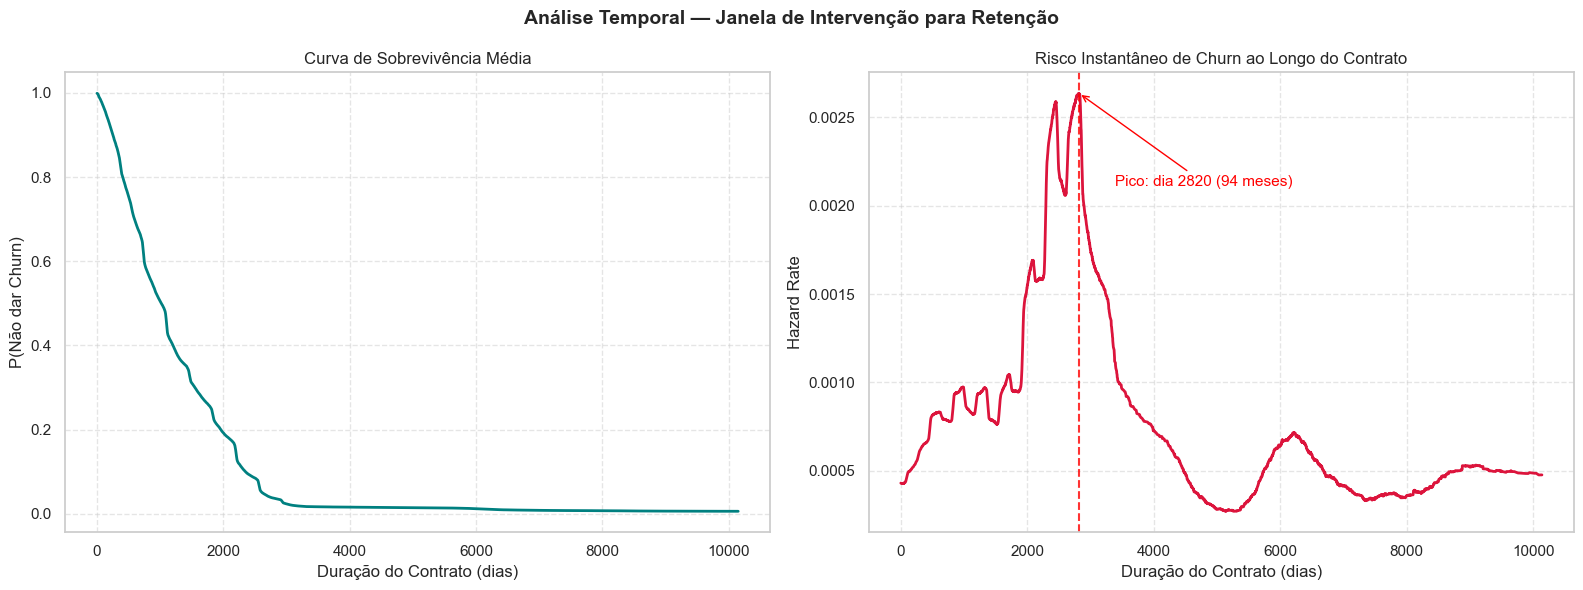


→ RECOMENDAÇÃO: Intervir ANTES do dia 2820 (94 meses de contrato)


In [ ]:
# Average survival curve + hazard rate → intervention window
# Subsample to avoid memory explosion
sample_size = 500
sample_val_idx = X_val[best_features].sample(sample_size, random_state=42).index

surv_funcs_all = rsf_plot.predict_survival_function(
    X_val[best_features].loc[sample_val_idx].astype(np.float32)
)

times    = surv_funcs_all[0].x
avg_surv = np.mean([sf.y for sf in surv_funcs_all], axis=0)

delta_s       = -np.diff(avg_surv)
hazard_approx = delta_s / (avg_surv[:-1] + 1e-9)
hazard_times  = times[:-1]
hazard_smooth = uniform_filter1d(hazard_approx, size=max(1, len(hazard_approx)//10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(times, avg_surv, color='teal', linewidth=2)
axes[0].set_title("Average Survival Curve")
axes[0].set_xlabel("Contract Duration (days)")
axes[0].set_ylabel("P(Not Churning)")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(hazard_times, hazard_smooth, color='crimson', linewidth=2)
peak_idx  = np.argmax(hazard_smooth)
peak_time = hazard_times[peak_idx]
axes[1].axvline(x=peak_time, color='red', linestyle='--', alpha=0.8)
axes[1].annotate(
    f'Peak: day {peak_time:.0f} ({peak_time/30:.0f} months)',
    xy=(peak_time, hazard_smooth[peak_idx]),
    xytext=(peak_time + max(30, peak_time*0.2), hazard_smooth[peak_idx] * 0.8),
    arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red'
)
axes[1].set_title("Instantaneous Churn Risk Over Contract Duration")
axes[1].set_xlabel("Contract Duration (days)")
axes[1].set_ylabel("Hazard Rate")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Temporal Analysis — Intervention Window for Retention", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n→ RECOMMENDATION: Intervene BEFORE day {peak_time:.0f} ({peak_time/30:.0f} months of contract)")

=== JANELA DE INTERVENCAO POR GRUPO ===
  Baixo Risco: pico no dia 2820 (94.0 meses) -> intervir antes do mes 92
  Medio Risco: pico no dia 2452 (81.7 meses) -> intervir antes do mes 80
  Alto Risco: pico no dia 992 (33.1 meses) -> intervir antes do mes 31


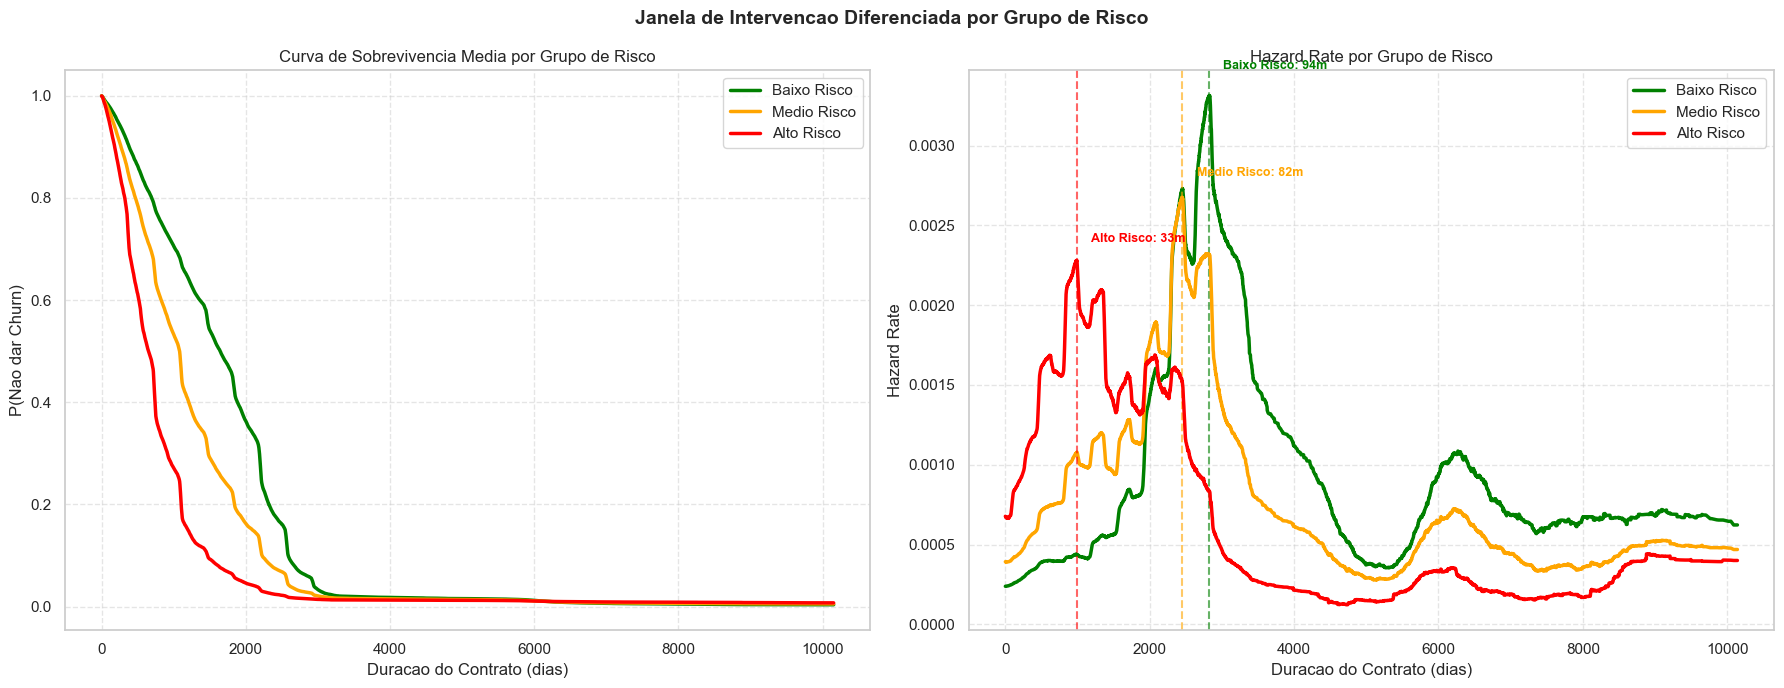

In [ ]:
# Hazard Rate by Risk Group — reuses surv_funcs_all from previous cell (no new predict)
# sample_val_idx and surv_funcs_all were already computed in the previous cell
# Associate each sample position to its risk group
sample_groups = val_surv_plot.loc[sample_val_idx, 'risk_group'].values
surv_by_group = {}
for group in ['Low Risk', 'Medium Risk', 'High Risk']:
    idxs = [i for i, g in enumerate(sample_groups) if g == group]
    surv_by_group[group] = [surv_funcs_all[i] for i in idxs]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors_grp = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}

print("=== INTERVENTION WINDOW BY GROUP ===")
for group in ['Low Risk', 'Medium Risk', 'High Risk']:
    sfs = surv_by_group[group]
    times_grp    = sfs[0].x
    avg_surv_grp = np.mean([sf.y for sf in sfs], axis=0)

    axes[0].plot(times_grp, avg_surv_grp, color=colors_grp[group], linewidth=2.5, label=group)

    delta_s_grp  = -np.diff(avg_surv_grp)
    hazard_grp   = delta_s_grp / (avg_surv_grp[:-1] + 1e-9)
    h_times_grp  = times_grp[:-1]
    h_smooth_grp = uniform_filter1d(hazard_grp, size=max(1, len(hazard_grp)//10))
    axes[1].plot(h_times_grp, h_smooth_grp, color=colors_grp[group], linewidth=2.5, label=group)

    peak_idx_grp = np.argmax(h_smooth_grp)
    peak_t_grp   = h_times_grp[peak_idx_grp]
    axes[1].axvline(x=peak_t_grp, color=colors_grp[group], linestyle='--', alpha=0.6)
    axes[1].annotate(
        f'{group}: {peak_t_grp/30:.0f}m',
        xy=(peak_t_grp, h_smooth_grp[peak_idx_grp]),
        xytext=(peak_t_grp + 200, h_smooth_grp[peak_idx_grp] * 1.05),
        fontsize=9, color=colors_grp[group], fontweight='bold'
    )
    intervene = max(1, round(peak_t_grp/30) - 2)
    print(f"  {group}: peak at day {peak_t_grp:.0f} ({peak_t_grp/30:.1f} months) -> intervene before month {intervene}")

axes[0].set_title("Average Survival Curve by Risk Group")
axes[0].set_xlabel("Contract Duration (days)")
axes[0].set_ylabel("P(Not Churning)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Hazard Rate by Risk Group")
axes[1].set_xlabel("Contract Duration (days)")
axes[1].set_ylabel("Hazard Rate")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Differentiated Intervention Window by Risk Group", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# % of Dossiers Churning per Month — by Risk Group
# Uses surv_by_group already computed in the previous cell (no new predict)

fig, ax = plt.subplots(figsize=(14, 6))
colors_grp = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}

churn_tables = {}
for group in ['Low Risk', 'Medium Risk', 'High Risk']:
    sfs = surv_by_group[group]
    times_grp    = sfs[0].x
    avg_surv_grp = np.mean([sf.y for sf in sfs], axis=0)

    # Interpolate to whole months
    max_months = int(times_grp[-1] / 30)
    months = np.arange(1, max_months + 1)
    surv_monthly = np.interp(months * 30, times_grp, avg_surv_grp)

    # % churn per month = survival curve drop (from total dossiers)
    surv_with_start = np.concatenate([[1.0], surv_monthly])
    churn_pct = np.diff(-surv_with_start) * 100

    ax.plot(months, churn_pct, color=colors_grp[group], linewidth=2, label=group)
    churn_tables[group] = pd.Series(churn_pct, index=months)

ax.set_title("% of Dossiers Churning per Month — by Risk Group")
ax.set_xlabel("Contract Month")
ax.set_ylabel("% of Dossiers Churning That Month")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Quarterly cumulative table by group
periodos = [(1,3,'Month 1-3'), (4,6,'Month 4-6'), (7,9,'Month 7-9'), (10,12,'Month 10-12'),
            (13,18,'Month 13-18'), (19,24,'Month 19-24'), (25,36,'Month 25-36'),
            (37,48,'Month 37-48'), (49,60,'Month 49-60')]

rows = []
for start, end, label in periodos:
    row = {'Period': label}
    for group in ['High Risk', 'Medium Risk', 'Low Risk']:
        s = churn_tables[group]
        valid = s[(s.index >= start) & (s.index <= end)]
        row[group] = f"{valid.sum():.1f}%" if len(valid) > 0 else "—"
    rows.append(row)

tabela = pd.DataFrame(rows)
print("=== CUMULATIVE % OF DOSSIERS CHURNING BY PERIOD AND GROUP ===")
print(tabela.to_string(index=False))